In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing
import random
import tensorflow as tf
import os

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [4]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [5]:
date_indices = np.arange(len(h2o_data['year'].values))

In [7]:
features, labels, feature_date_indices = ppd('H2O', 
                                             h2o_data, 
                                             h2o_flags, 
                                             date_indices, 
                                             n_surrounding = 4, 
                                             n_altitudes = len(h2o_data['altitude'].values),
                                             filter_indices = True
                                             )

VMR for date index 256 is empty after screening
VMR for date index 1753 is empty after screening
VMR for date index 2319 is empty after screening
VMR for date index 2506 is empty after screening
VMR for date index 4293 is empty after screening
VMR for date index 4316 is empty after screening
VMR for date index 4591 is empty after screening
VMR for date index 4683 is empty after screening
VMR for date index 4695 is empty after screening
VMR for date index 4773 is empty after screening
VMR for date index 5448 is empty after screening
VMR for date index 5617 is empty after screening
VMR for date index 5743 is empty after screening
VMR for date index 6082 is empty after screening
VMR for date index 6844 is empty after screening
VMR for date index 7916 is empty after screening
VMR for date index 7917 is empty after screening
VMR for date index 7977 is empty after screening
VMR for date index 7989 is empty after screening
VMR for date index 8142 is empty after screening
VMR for date index 83

KeyboardInterrupt: 

In [ ]:
# Save features, labels and feature date indices as .npz file

# Specify the path to your USB drive
save_dir = "/Volumes/USB DRIVE/MPhys Project Data"

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save all arrays in a single .npz file
np.savez_compressed(
    os.path.join(save_dir, "data.npz"),
    features=features,
    labels=labels,
    feature_date_indices=feature_date_indices
)

In [6]:
# Load the .npz file
save_dir = "/Volumes/USB DRIVE/MPhys Project Data"
data = np.load(os.path.join(save_dir, "data.npz"))
features = data["features"]
labels = data["labels"]
feature_date_indices = data["feature_date_indices"]

In [7]:
n_profiles = features.shape[1]
n_altitudes = 150
n_features = features.shape[3] - 1

In [8]:
features.shape

(125194, 5, 150, 11)

In [9]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{0: 124340, 1: 854}


In [10]:
from keras import layers, models
from tensorflow.keras.layers import Layer
from keras.optimizers import Adam
from keras.regularizers import l2


In [11]:


def binary_accuracy_with_threshold(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

class ContextualAttention(Layer):
    def __init__(self):
        super(ContextualAttention, self).__init__()

    def call(self, query, key, value, indicator):
        """
        Contextual attention mechanism.

        Parameters:
        - query, key, value: Outputs from the LSTM or similar layers.
        - indicator: Binary indicator for the current profile (shape: [batch_size, n_profiles]).
        
        Returns:
        - attention_output: Weighted sum of value vectors.
        - attention_weights: Attention scores for all profiles.
        """
        # Compute raw attention scores (dot product between query and key)
        scores = tf.matmul(query, key, transpose_b=True)  # [batch_size, n_profiles, n_profiles]

        # Scale scores to avoid large values
        scores = scores / tf.sqrt(tf.cast(tf.shape(key)[-1], tf.float32))

        # Add bias for the current profile
        current_profile_bias = tf.expand_dims(indicator, axis=1)  # [batch_size, 1, n_profiles]
        scores += current_profile_bias  # Encourage attention on the current profile

        # Normalize scores using softmax
        attention_weights = tf.nn.softmax(scores, axis=-1)  # [batch_size, n_profiles, n_profiles]

        # Compute weighted sum of value
        attention_output = tf.matmul(attention_weights, value)  # [batch_size, n_profiles, value_dim]

        return attention_output, attention_weights
    
def compute_saliency_with_contextual_attention(model, X, indicators):
    """
    Compute saliency with the contextual attention model.
    """
    X_tensor = tf.convert_to_tensor(X)
    indicators_tensor = tf.convert_to_tensor(indicators)

    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model([X_tensor, indicators_tensor])
    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())



In [12]:
def build_contextual_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    inputs = tf.keras.Input(shape=(n_profiles, n_altitudes, n_features))
    indicators = tf.keras.Input(shape=(n_profiles,))  # Input for indicator feature

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        
        ])
    )(inputs)

    # LSTM layer
    lstm = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-1))(cnn)

    # Contextual Attention layer
    attention_layer = ContextualAttention()
    attention_output, attention_weights = attention_layer(lstm, lstm, lstm, indicators)

    # Aggregate attention output along profiles
    aggregated_attention = layers.GlobalAveragePooling1D()(attention_output)

    # Fully connected layers
    dense = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(aggregated_attention)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-3))(dense)

    # Build the model
    model = tf.keras.Model(inputs=[inputs, indicators], outputs=outputs)

    # Compile the model
    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])
    return model

In [26]:
# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features), kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ])
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3))(cnn)

    # Attention Layer
    attention_layer = layers.Attention()
    attention_scores = attention_layer([lstm, lstm])  # Self-attention: query and key/value are the same
    attention_output = layers.GlobalAveragePooling1D()(attention_scores) # Aggregate the attention scores along profiles


    # Fully connected layers
    dense = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(attention_output)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-3))(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [13]:
model = build_contextual_cnn_lstm_model(n_profiles, n_altitudes, n_features)

2024-12-17 22:30:39.388300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-12-17 22:30:39.388406: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-12-17 22:30:39.388479: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-12-17 22:30:39.388509: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-12-17 22:30:39.388526: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
from keras._tf_keras.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [15]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp, indices_train, indices_temp = train_test_split(features, labels, range(len(labels)), test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test, indices_val, indices_test = train_test_split(X_temp, y_temp, indices_temp, test_size=0.5, random_state=42)

In [16]:
X_train_indicators = X_train[..., -1]
X_train_indicators = X_train_indicators[:, :, 0]
X_train = X_train[..., :-1]

X_val_indicators = X_val[..., -1]
X_val_indicators = X_val_indicators[:, :, 0]
X_val = X_val[..., :-1]

X_test_indicators = X_test[..., -1]
X_test_indicators = X_test_indicators[:, :, 0]
X_test = X_test[..., :-1]



In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
# Smoothed class weights

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [ ]:
# Intermediate Class weights

intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

Epoch 1/20


/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(
2024-12-17 22:32:24.415818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1370/1370 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - binary_accuracy_with_threshold: 0.6569 - loss: 7.0715 - val_binary_accuracy_with_threshold: 0.4770 - val_loss: 1.0423
Epoch 2/20
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 65s 48ms/step - binary_accuracy_with_threshold: 0.3833 - loss: 0.9567 - val_binary_accuracy_with_threshold: 0.4043 - val_loss: 0.8548
Epoch 3/20
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - binary_accuracy_with_threshold: 0.5381 - loss: 0.8105 - val_binary_accuracy_with_threshold: 0.2460 - val_loss: 0.8677
Epoch 4/20
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - binary_accuracy_with_threshold: 0.5541 - loss: 0.7695 - val_binary_accuracy_with_threshold: 0.6048 - val_loss: 0.7051
Epoch 5/20
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - binary_accuracy_with_threshold: 0.5363 - loss: 0.7569 - val_binary_accuracy_with_threshold: 0.7023 - val_loss: 0.6793
Epoch 6/20
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 63s 46ms/step - binary_accuracy_with_threshold: 0.5033 - loss: 0.7612 - val_binary_accura

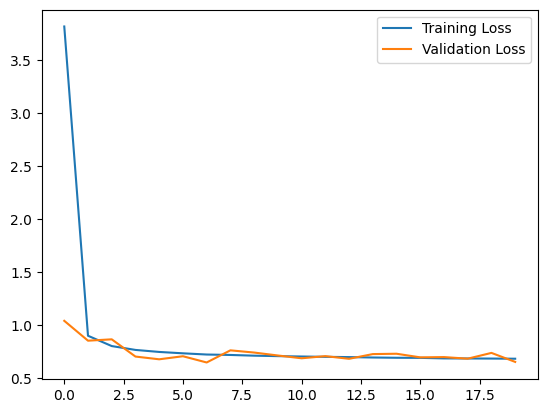

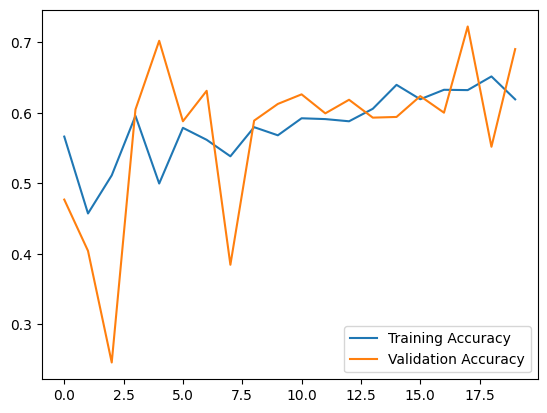

In [18]:
# Train the model
history = model.fit(
    [X_train, X_train_indicators], y_train,
    epochs=20,
    batch_size=64,
    validation_data=([X_val, X_val_indicators], y_val),
    #callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy_with_threshold'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy_with_threshold'], label='Validation Accuracy')
plt.legend()
plt.show()

In [20]:
model.save("/Volumes/USB DRIVE/MPhys Project Data/model.keras")

In [ ]:
model = tf.keras.models.load_model("/Volumes/USB DRIVE/MPhys Project Data/model.keras")

In [21]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate([X_test, X_test_indicators], y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - binary_accuracy_with_threshold: 0.6933 - loss: 0.6585
Test Loss: 0.6558714509010315, Test Accuracy: 0.6925985217094421


/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
              precision    recall  f1-score   support

           0       0.99      0.69      0.82     18655
           1       0.01      0.42      0.02       125

    accuracy                           0.69     18780
   macro avg       0.50      0.56      0.42     18780
weighted avg       0.99      0.69      0.81     18780



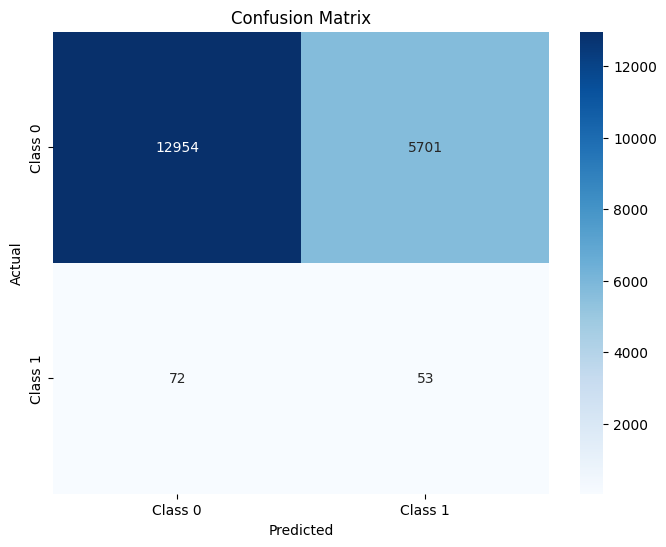

In [22]:
# Get predictions
predictions = model.predict([X_test, X_test_indicators])

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]
X_test_sample_indicators = X_test_indicators[random_indices]

def compute_saliency(model, X):
    X_tensor = tf.convert_to_tensor(X)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)

    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())

saliency = compute_saliency(model, X_test_sample)
print(saliency.shape)

# Aggregate over features
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate over profiles and altitudes
n_altitudes = 150
n_features = 11

feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "year": feature_importance[3],
    "month": np.sum(feature_importance[4:6]),
    "day": np.sum(feature_importance[6:8]),
    "hour": np.sum(feature_importance[8:10]),
    #"Time Features": np.sum(feature_importance[3:10]),  # Sum of 7 time features
    "Indicator": feature_importance[10],
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance for Quality Prediction")
plt.show()

ValueError: Can't convert non-rectangular Python sequence to Tensor.

In [23]:
predicted_bad_indices = np.where(discrete_predictions == 1)[0]
actual_bad_indices = np.where(y_test == 1)[0]

predicted_bad_indices_TP = np.intersect1d(predicted_bad_indices, actual_bad_indices)

predicted_bad_indices_TP.shape

(53,)

17540
[109803 109804 109805 109806 109807]


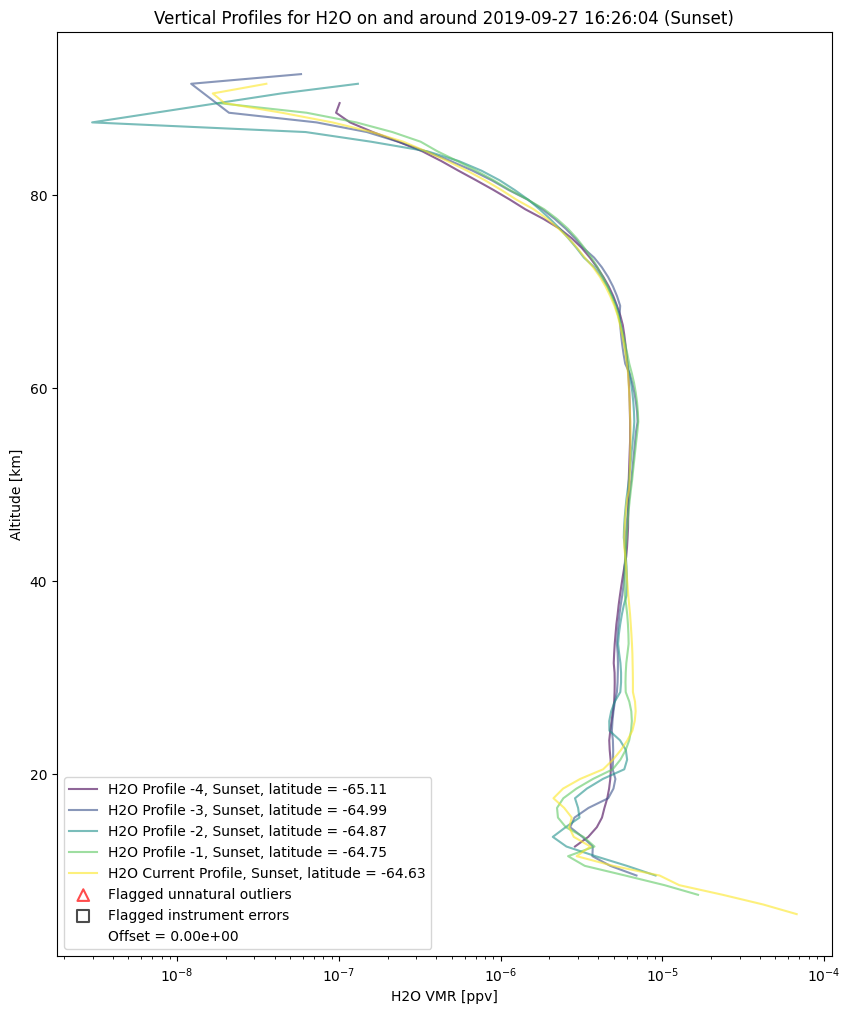

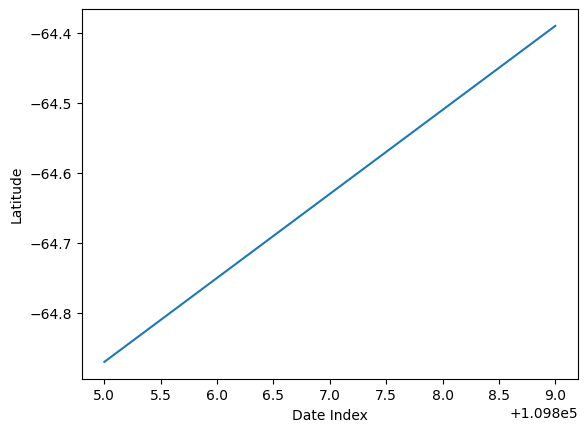

In [24]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp
#18612
idx = np.random.choice(predicted_bad_indices)
print(idx)

test_date_indices = feature_date_indices[indices_test]
date_indices_example = test_date_indices[idx]
print(date_indices_example)

date_indices_example_after = date_indices_example + 2

vpp('H2O', h2o_data, h2o_flags, date_indices_example)


latitudes = h2o_data['latitude'][date_indices_example_after].values
plt.figure()

plt.plot(date_indices_example_after, latitudes)
plt.xlabel('Date Index')
plt.ylabel('Latitude')
plt.show()


(1, 5, 150, 10)
(1, 5, 150, 10)


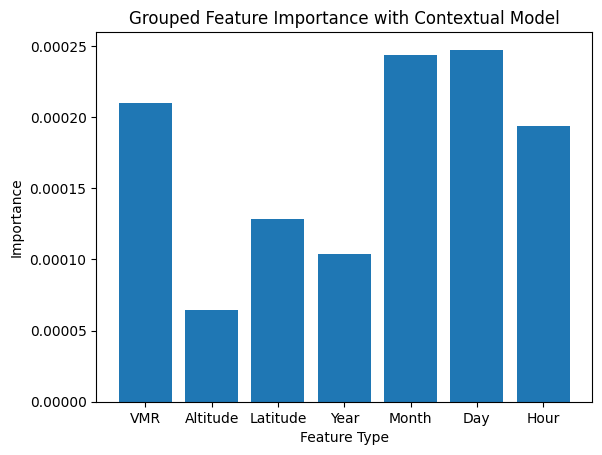

In [31]:
# Feature importance for contextual model in making predictions for specificly randomly sampled sample

# Sample random indices for evaluation
random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[idx]
X_test_sample = X_test_sample[np.newaxis, ...]
print(X_test_sample.shape)
X_test_sample_indicators = X_test_indicators[idx]
X_test_sample_indicators = X_test_sample_indicators[np.newaxis, ...]
X_test_sample_indicators_perturbed = X_test_sample_indicators.copy()

# Compute saliency
saliency = compute_saliency_with_contextual_attention(model, X_test_sample, X_test_sample_indicators)
print(saliency.shape)

# Aggregate saliency over profiles and altitudes
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate across samples, profiles, and altitudes
n_altitudes = len(h2o_data['altitude'].values)
n_features = 10

# Define feature groups
feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "Year": feature_importance[3],
    "Month": np.sum(feature_importance[4:6]),
    "Day": np.sum(feature_importance[6:8]),
    "Hour": np.sum(feature_importance[8:10]),
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance with Contextual Model")
plt.show()

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
[[0.14857689 0.1493396  0.1493016  0.14894931 0.4038326 ]
 [0.14831941 0.14944422 0.14943075 0.14900517 0.4038005 ]
 [0.14785206 0.14899783 0.14913219 0.14903344 0.40498444]
 [0.1468669  0.14793257 0.14839056 0.14907087 0.40773904]
 [0.14561884 0.1466088  0.1474659  0.14911214 0.4111943 ]]
[0.2        0.2        0.2        0.19999999 0.2       ]


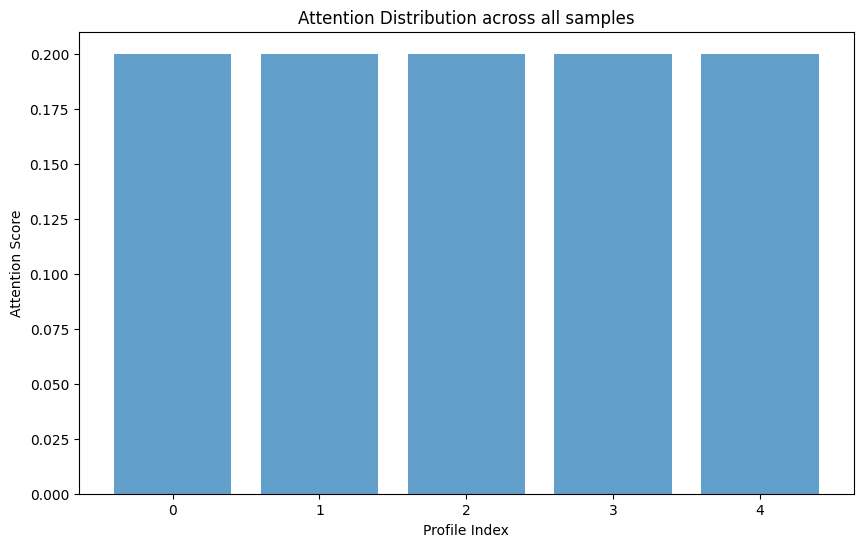

In [35]:
# Attention level for each profile (averaged) after introduction of custom attention mechanism

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators])[idx]

print(attention_scores)

profile_contributions = np.sum(attention_scores, axis=1)  # Average over samples

profile_contributions = profile_contributions/np.sum(profile_contributions)
print(profile_contributions)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), profile_contributions, alpha=0.7)  # Attention for profile 4
plt.title(f"Attention Distribution across all samples")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 150,    │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 4608)   │     26,688 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 5, 128)    │  2,425,344 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contextual_attenti… │ [(None, 5, 128),  │          0 │ lstm[0][0],       │
│ (ContextualAttenti… │ (None, 5, 5)]     │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0],       │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ contextual_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,381,061 (28.16 MB)

 Trainable params: 2,460,353 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,920,708 (18.77 MB)

In [61]:
# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("attention").output  # Replace with the actual index or name
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict(X_test[:2000])

print("Attention Scores Shape:", attention_scores.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Attention Scores Shape: (2000, 5, 128)


587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


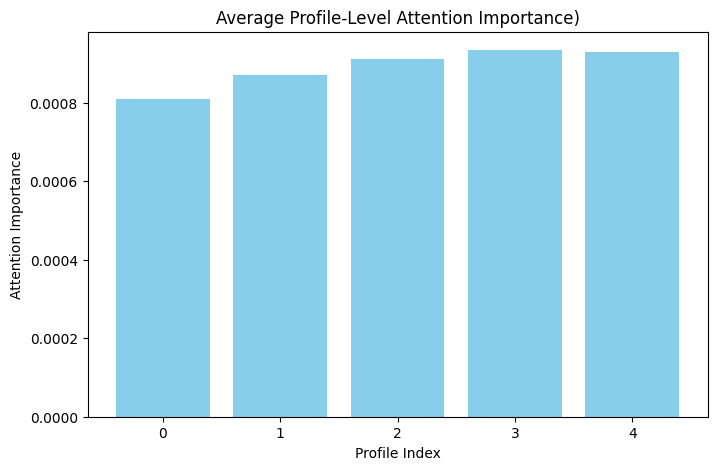

In [ ]:
# Attention level of each profile (averaged) prior to introduction of custom attention mechanism

random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]

attention_scores = attention_extractor.predict(X_test)

# Aggregate attention scores across the feature dimension (axis=-1)
profile_importance = np.mean(attention_scores, axis=-1)  # Shape: (n_samples, n_profiles)

average_profile_importance = np.mean(profile_importance, axis=0)
sample_idx = 7

# Visualize attention for the first sample
plt.figure(figsize=(8, 5))
plt.bar(range(profile_importance.shape[1]), average_profile_importance, color='skyblue')
plt.xlabel("Profile Index")
plt.ylabel("Attention Importance")
plt.title(f"Average Profile-Level Attention Importance)")
plt.show()

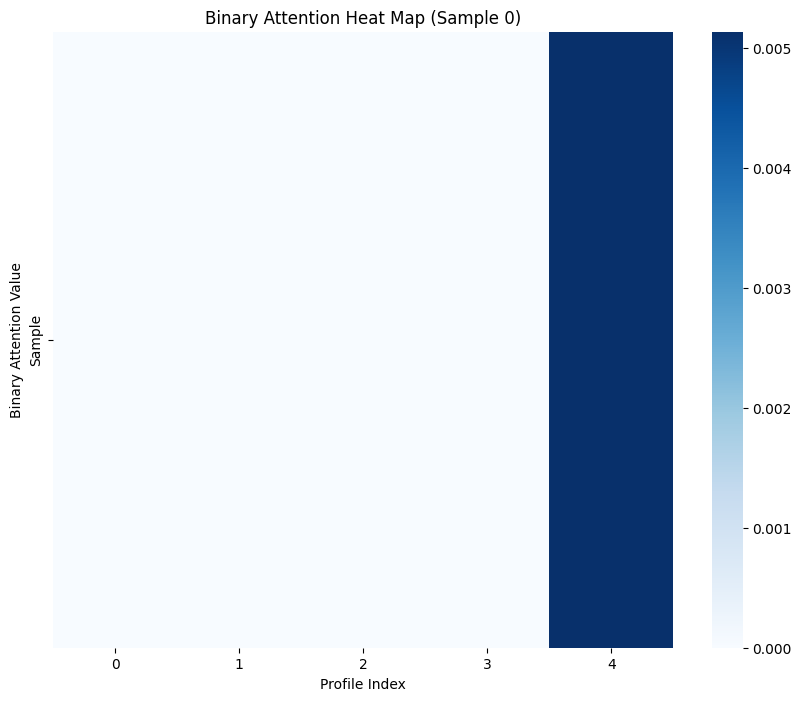

In [ ]:
# Attention heat map for the first sample prior to introduction of custom atttention mechanism

# Aggregate attention scores across the last axis (n_attention_scores)
attention_scores_aggregated = np.mean(attention_scores, axis=2)  # Shape: (n_samples, n_profiles)

# Extract binary indicators for all samples and profiles
binary_indicators = X_test[:, :, 0, -1]  # Shape: (n_samples, n_profiles), assuming indicator is at the last feature index

# Initialize binary attention maps
binary_attention_maps = np.zeros_like(attention_scores_aggregated)  # Shape matches aggregated scores

# Iterate over each sample
for sample_idx in range(binary_attention_maps.shape[0]):  # Loop over samples
    for profile_idx in range(binary_attention_maps.shape[1]):  # Loop over profiles
        if binary_indicators[sample_idx, profile_idx] == 1:  # Check if indicator is 1
            binary_attention_maps[sample_idx, profile_idx] = attention_scores_aggregated[sample_idx, profile_idx]

# Visualize binary attention heat map for the first sample
sample_index = 0  # Choose the sample to visualize
plt.figure(figsize=(10, 8))
sns.heatmap(binary_attention_maps[sample_index].reshape(1, -1),  # Use a single row for visualization
            annot=False, cmap="Blues", cbar=True, xticklabels=range(binary_attention_maps.shape[1]), yticklabels=["Sample"])
plt.title(f"Binary Attention Heat Map (Sample {sample_index})")
plt.xlabel("Profile Index")
plt.ylabel("Binary Attention Value")
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


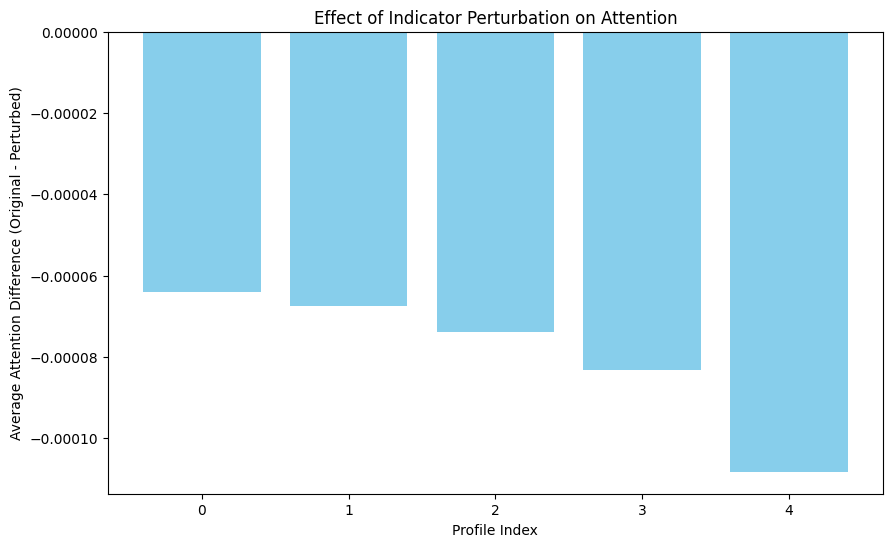

In [ ]:
# Change in attention per profile after perturbation of indicator feature prior to introduction of custom attention mechanism

X_test_perturbed = X_test.copy()
X_test_perturbed[:, :, :, -1] = 0  # Set all indicator values to 0

# Extract attention scores for original data
original_attention_scores = attention_extractor.predict(X_test)

# Extract attention scores for perturbed data
perturbed_attention_scores = attention_extractor.predict(X_test_perturbed)

original_attention_scores_aggregated = np.mean(original_attention_scores, axis=2)
perturbed_attention_scores_aggregated = np.mean(perturbed_attention_scores, axis=2)

# Compute the difference
attention_difference = original_attention_scores_aggregated - perturbed_attention_scores_aggregated

average_attention_difference = np.mean(attention_difference, axis=0)  # Shape: (n_profiles,)

# Visualize for a single sample (e.g., sample 0)
sample_index = 0
plt.figure(figsize=(10, 6))
plt.bar(range(attention_difference.shape[1]), average_attention_difference, color="skyblue")
plt.xlabel("Profile Index")
plt.ylabel("Average Attention Difference (Original - Perturbed)")
plt.title(f"Effect of Indicator Perturbation on Attention")
plt.show()



587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


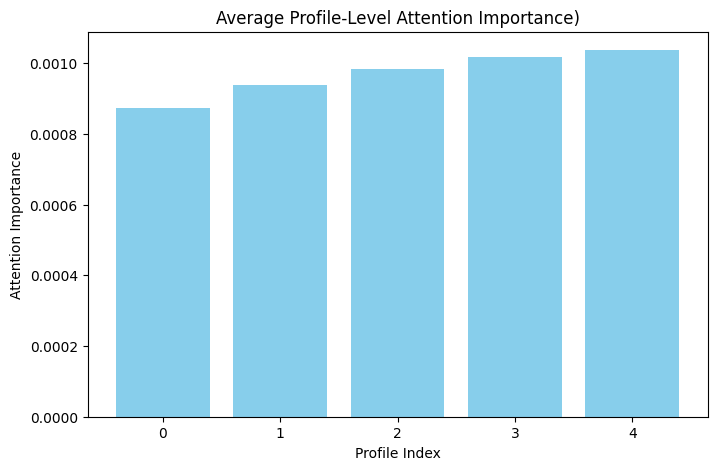

In [ ]:
# Attention level of each profile (averaged) after perturbation of indicator feature prior to introduction of custom attention mechanism

attention_scores = attention_extractor.predict(X_test_perturbed)

# Aggregate attention scores across the feature dimension (axis=-1)
profile_importance = np.mean(attention_scores, axis=-1)  # Shape: (n_samples, n_profiles)

average_profile_importance = np.mean(profile_importance, axis=0)
sample_idx = 7

# Visualize attention for the first sample
plt.figure(figsize=(8, 5))
plt.bar(range(profile_importance.shape[1]), average_profile_importance, color='skyblue')
plt.xlabel("Profile Index")
plt.ylabel("Attention Importance")
plt.title(f"Average Profile-Level Attention Importance)")
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
[[0.14873669 0.14970048 0.14989056 0.14925617 0.402416  ]
 [0.14864242 0.15023915 0.15056248 0.14952618 0.4010298 ]
 [0.14855967 0.15028785 0.15066712 0.14959185 0.40089357]
 [0.14847465 0.14980203 0.15014167 0.14943841 0.4021433 ]
 [0.14843409 0.14897573 0.14919724 0.14911428 0.40427864]]
[0.14437325 0.14702067 0.14893392 0.15013275 0.40954468]


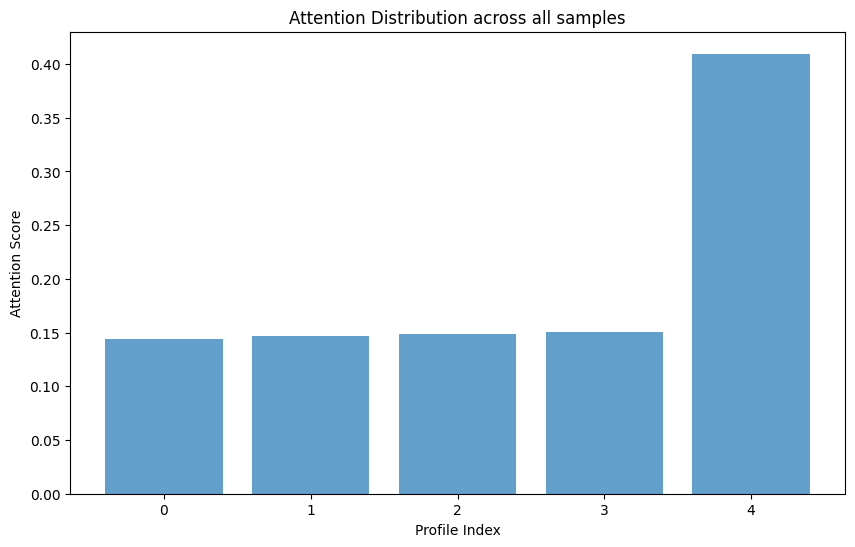

In [ ]:
# Attention level for each profile (averaged) after introduction of custom attention mechanism

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators])

print(attention_scores[0])

average_attention_scores = np.mean(attention_scores, axis=(0,1))  # Average over samples

print(average_attention_scores)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), average_attention_scores, alpha=0.7)  # Attention for profile 4
plt.title(f"Attention Distribution across all samples")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

  1/587 ━━━━━━━━━━━━━━━━━━━━ 1:42 175ms/step

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
[[0.19947937 0.20077197 0.20102689 0.20017609 0.19854574]
 [0.19911887 0.20125785 0.20169096 0.20030275 0.19762953]
 [0.19898508 0.20129983 0.20180786 0.20036758 0.19753958]
 [0.19908185 0.20086165 0.20131706 0.20037411 0.19836529]
 [0.19938834 0.20011593 0.20041348 0.20030205 0.19978021]]
[0.19476327 0.19835664 0.20097363 0.20258676 0.20331989]


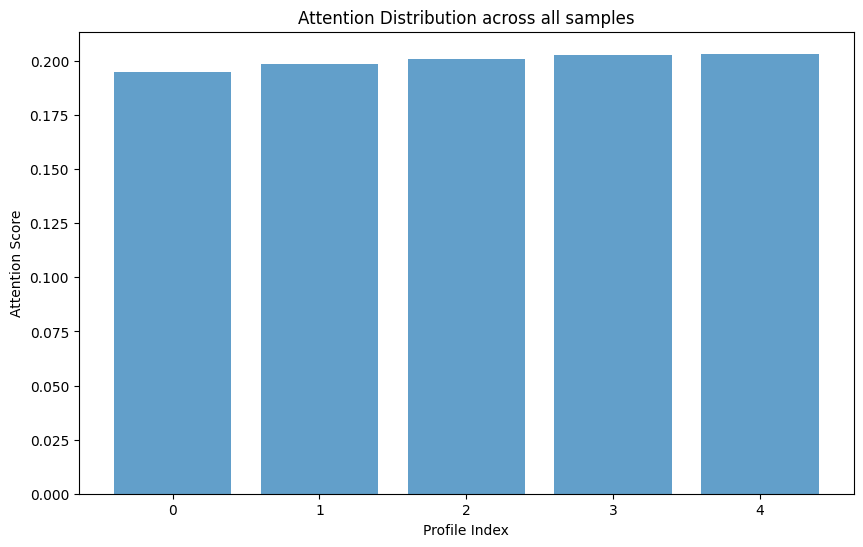

In [ ]:
# Attention level per profile after perturbation of indicator feature after introduction of custom attention mechanism

X_test_indicators_perturbed = X_test_indicators.copy()
X_test_indicators_perturbed[:,4] = 0

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators_perturbed])

print(attention_scores[0])

average_attention_scores = np.mean(attention_scores, axis=(0,1))  # Average over samples

print(average_attention_scores)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), average_attention_scores, alpha=0.7)  # Attention for profile 4
plt.title(f"Perturbed Attention Distribution across all samples")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

In [58]:
def compute_saliency_with_contextual_attention(model, X, indicators):
    """
    Compute saliency with the contextual attention model.
    """
    X_tensor = tf.convert_to_tensor(X)
    indicators_tensor = tf.convert_to_tensor(indicators)

    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model([X_tensor, indicators_tensor])
    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())

# Sample

(2000, 5, 150, 10)


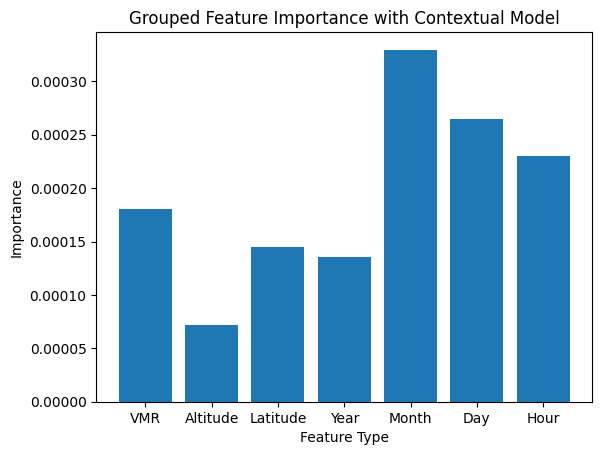

In [32]:
# Sample random indices for evaluation
random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]
X_test_sample_indicators = X_test_indicators[random_indices]
X_test_sample_indicators_perturbed = X_test_sample_indicators.copy()

# Compute saliency
saliency = compute_saliency_with_contextual_attention(model, X_test_sample, X_test_sample_indicators)
print(saliency.shape)

# Aggregate saliency over profiles and altitudes
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate across samples, profiles, and altitudes
n_altitudes = len(h2o_data['altitude'].values)
n_features = 10

# Define feature groups
feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "Year": feature_importance[3],
    "Month": np.sum(feature_importance[4:6]),
    "Day": np.sum(feature_importance[6:8]),
    "Hour": np.sum(feature_importance[8:10]),
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance with Contextual Model")
plt.show()